# Quickstart

In [1]:
import tskit

# Bump the default tskit SVG canvas so branches have more horizontal room.
# Also omit per-site mutation glyphs by default: a local tree's interval
# can carry multiple segregating sites, and we annotate at most one via
# tip labels, the rest clutter the SVG.
_orig_draw_svg = tskit.Tree.draw_svg

def _wide_draw_svg(self, *args, **kwargs):
    kwargs.setdefault("size", (400, 240))
    kwargs.setdefault("omit_sites", True)
    return _orig_draw_svg(self, *args, **kwargs)

tskit.Tree.draw_svg = _wide_draw_svg


## Single tree example

We begin with a single local tree of the ARG (simulated as shown at the end of this page), the one spanning the leftmost polymorphic site, and infer the ancestral state at that site.

INFO:ancestree.TskitSource: Reading variants from a tree sequence (224 sites, 8 samples)


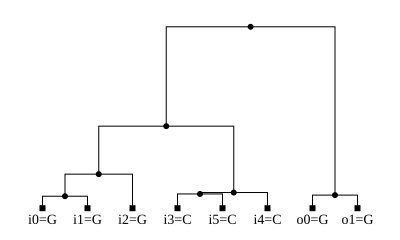

In [2]:
import ancestree as anc
import tskit
from IPython.display import SVG

ts = tskit.load("quickstart.trees")
site = next(iter(anc.TskitSource(ts)))  # leftmost polymorphic site
tree = anc.TskitLocalTree(ts, position=site.pos)  # local tree spanning it
SVG(tree.draw_svg(site=site, time_scale="time"))


Subclades A (`i0..i2`) and B (`i3..i5`) are monophyletic, and the outgroups (`o0..o1`) sit on a deeper branch.

:::{note}
In ARG mode and local-tree mode the kernel treats every tip symmetrically: no sample is weighted differently for being an outgroup. The ingroup and outgroup names instead set the focal node, the node the posterior is reported at. When both are given, samples belonging to neither are excluded from the inference. By default it is the most recent common ancestor of the ingroup samples, so its state is the ingroup's ancestral allele. The {paramref}`focal <ancestree.inference.ARGBasedInference.focal>` argument moves it, and {doc}`focal_node` covers the choices.
:::


In [3]:
ingroup = [f"i{i}" for i in range(6)]
outgroup = ["o0", "o1"]

inf = anc.Inference.from_arg(
    ts, model=anc.JC69(), mu=5e-8,
    ingroup_samples=ingroup, outgroup_samples=outgroup,
)
post = inf.infer_site(tree, site)
print(post)


Posterior({'A': 0.0000, 'C': 0.0005, 'G': 0.9995, 'T': 0.0000})


In [4]:
assert post.map_allele == "G" and post["G"] > 0.99


Subclade B (`i3..i5`) carries the derived `C`, while subclade A (`i0..i2`) and both outgroups carry the ancestral `G`. That is strong evidence for a single `G → C` mutation on the branch above B's MRCA, and indeed the posterior places almost all its mass on `G`.

Every mode evaluates the same kernel, Felsenstein's pruning algorithm ({class}`~ancestree.likelihood.Likelihood`): given a rooted tree, the tip alleles and a substitution model, it returns $\log P(\text{tips} \mid \text{root} = s)$ for each state $s$, which the inference normalises against the prior at the reporting node.


## ARG with outgroups

We infer every variant in the tree sequence and grade the assignments against the simulator's truth (see {doc}`arg_based_inference`).


In [5]:
print(f"{ts.num_samples} samples, {ts.num_trees} local trees, {ts.num_sites} sites")


8 samples, 29 local trees, 224 sites


{meth}`Inference.infer() <ancestree.inference.Inference.infer>` walks every local tree and yields a `(Site, Posterior)` pair per variant, and {class}`~ancestree.posterior.Grade` scores those pairs two ways: MAP recovery, the fraction of sites whose highest-posterior allele is the true one, and the mean Brier score $\sum_a (p_a - \mathbb{1}[a = \text{truth}])^2$ over the alleles $a$, which is lower the better the posterior is calibrated. The Brier score exposes posterior calibration that the binary check hides. {meth}`Grade.truth_at_focal() <ancestree.posterior.Grade.truth_at_focal>` reads the true allele off the simulated ARG at the run's focal node, the ingroup MRCA of each true local tree.

The runs are graded on the sites polymorphic within the ingroup, selected by {class}`~ancestree.sites.PolymorphicSiteFilter`. The posterior is evaluated at the ingroup MRCA, which is uninformative at a site where the ingroup is monomorphic: the state there is the ingroup's own allele. Such sites want a reporting node closer to the panel root (see {doc}`focal_node`), so they are excluded here.


In [6]:
inf_full = anc.Inference.from_arg(
    ts, model=anc.JC69(), mu=5e-8,
    ingroup_samples=ingroup, outgroup_samples=outgroup,
)
res_full = list(inf_full.infer())


INFO:ancestree.ARGBasedInference: Inferring the ancestral allele at 224 sites over 29 local trees from the ARG
INFO:ancestree.ARGBasedInference: Using 6 ingroup sample(s): i0, i1, i2, i3, i4, i5
INFO:ancestree.ARGBasedInference: Using 2 outgroup sample(s): o0, o1
ARGBasedInference: 100%|██████████| 29/29 [00:00<00:00, 3974.21 trees/s]
INFO:ancestree.ARGBasedInference: Focal node: reported at the ingroup_mrca; 4 tree(s) where the ingroup is not monophyletic, so its MRCA subtends outgroup tips


For memory reasons an inference keeps no posteriors, so every consumer of {meth}`Inference.infer() <ancestree.inference.Inference.infer>` streams them afresh. The output here is small, so it is materialised into a list.


In [7]:
keep = anc.PolymorphicSiteFilter(samples=ingroup)
truth = anc.Grade.truth_at_focal(ts, ingroup_samples=ingroup, outgroup_samples=outgroup)
anc.Grade(res_full, truth, filter=keep)


118 sites: MAP recovery 98.3%; mean Brier = 0.031

## Ingroup-only ARG

Without outgroups we expect limited ancestral-state information, as there is no deep branch to anchor the root. The ingroup topology nonetheless carries signal: sites where a single ingroup branch carries the derived allele are readily resolved, and the kernel recovers the major allele as ancestral most of the time. We drop the outgroups via {meth}`TreeSequence.simplify() <tskit.TreeSequence.simplify>` to measure how much recovery degrades without them.

In [8]:
nodes = anc.TskitLocalTree.sample_map_from_individuals(ts)
ts_ing = ts.simplify(samples=[nodes[n] for n in ingroup], keep_unary=False)

inf_ing = anc.Inference.from_arg(
    ts_ing, model=anc.JC69(), mu=5e-8,
    ingroup_samples=ingroup,
)
res_ing = list(inf_ing.infer())


INFO:ancestree.ARGBasedInference: Inferring the ancestral allele at 155 sites over 18 local trees from the ARG
INFO:ancestree.ARGBasedInference: Using 6 ingroup sample(s): i0, i1, i2, i3, i4, i5
ARGBasedInference: 100%|██████████| 18/18 [00:00<00:00, 4426.97 trees/s]
INFO:ancestree.ARGBasedInference: Focal node: reported at the ingroup_mrca


In [9]:
anc.Grade(res_ing, truth, filter=keep)


118 sites: MAP recovery 85.6%; mean Brier = 0.168

## Local trees from genotypes

Usually no ARG is available, only variant data. In addition, inferring the ARG itself often
requires the ancestral allele at every site as input, as with tsinfer and
Relate. Two routes recover the
ancestral state from genotypes alone. The first,
{class}`~ancestree.local_tree_inference.LocalTreeInference`, infers a dated
local tree of the sample per genomic window (a pairwise-coalescent HMM, then
per-window UPGMA) and runs the ARG-mode kernel on each.
{meth}`Inference.from_local_tree() <ancestree.inference.Inference.from_local_tree>`
constructs it (see {doc}`local_tree_inference`).


The VCF the inference reads is exported from the tree sequence.


In [10]:
with open("quickstart.vcf", "w") as vcf:
    ts.write_vcf(vcf, contig_id="1", individual_names=ingroup + outgroup)


Local-tree mode infers the genealogy from that VCF and scores the sites on it, with no access to the true ARG.


In [11]:
lt_inf = anc.Inference.from_local_tree(
    "quickstart.vcf", model=anc.JC69(), mu=5e-8, rec_rate=1e-8,
    ingroup_samples=ingroup, outgroup_samples=outgroup,
    sequence_length=ts.sequence_length,
)
res_lt = list(lt_inf.infer())


INFO:ancestree.CyVCF2Source: Genotypes read as ploidy 1; pass ploidy= to override
INFO:ancestree.CyVCF2Source: Reading variants from quickstart.vcf (8 haplotype samples)
INFO:ancestree.LocalTreeInference: Inferring local trees from genotypes (8 samples, window=8snp)
INFO:ancestree.LocalTreeInference: Using 6 ingroup sample(s): i0, i1, i2, i3, i4, i5
INFO:ancestree.LocalTreeInference: Using 2 outgroup sample(s): o0, o1
LocalTreeInference: 100%|██████████| 1/1 [00:00<00:00, 40.68 segments/s]
INFO:ancestree.LocalTreeInference: Focal node: reported at the ingroup_mrca


In [12]:
anc.Grade(res_lt, truth, filter=keep)


118 sites: MAP recovery 98.3%; mean Brier = 0.028

## Fixed-tree inference

The second route assumes a single topology for every site rather than inferring
one. The branch rates of a fixed tree are fitted by maximum likelihood against
the polymorphic and monomorphic-site evidence, and the ancestral state at each
site is then scored under the fitted tree. The branches above the ingroup come
from the assumed placement of the outgroups rather than from an inferred
genealogy (see {doc}`fixed_tree_inference`).


{meth}`Inference.from_fixed_tree() <ancestree.inference.Inference.from_fixed_tree>` reads the VCF exported from the tree sequence and returns a {class}`FixedTreeInference <ancestree.inference.FixedTreeInference>`, which builds the outgroup-ladder topology from the supplied names, ML-fits the branch rates and annotates every site. {meth}`FixedTreeInference.fit() <ancestree.inference.FixedTreeInference.fit>` returns the fitted branch rates, one per ladder branch.


In [13]:
vcf_inf = anc.Inference.from_fixed_tree(
    "quickstart.vcf",
    ingroup_samples=ingroup,
    outgroup_samples=outgroup,  # closest first
    model=anc.JC69(),
    n_target_sites=int(ts.sequence_length),
)
vcf_inf.fit();


INFO:ancestree.CyVCF2Source: Genotypes read as ploidy 1; pass ploidy= to override
INFO:ancestree.CyVCF2Source: Reading variants from quickstart.vcf (8 haplotype samples)
INFO:ancestree.FixedTreeInference: Streaming fit: pass 1 (config histogram) complete; fitting 3 branch rate(s) by ML, then a second streaming pass emits posteriors.
INFO:ancestree.FixedTreeInference: 10/10 L-BFGS-B starts converged; best is start 7 (log L -70267.9684, range 0.0000); winning fit took 14 iterations
INFO:ancestree.FixedTreeInference: MLE branch rates: K0=2.0240e-03, K1=3.9986e-05, K2=6.0017e-05
INFO:ancestree.FixedTreeInference: Ingroup MRCA → outgroup divergences: o0=2.0640e-03, o1=2.0840e-03


In [14]:
res_vcf = list(vcf_inf.infer())


INFO:ancestree.FixedTreeInference: Using 6 ingroup sample(s): i0, i1, i2, i3, i4, i5
INFO:ancestree.FixedTreeInference: Using 2 outgroup sample(s): o0, o1
INFO:ancestree.FixedTreeInference: Inferring the ancestral allele on the fitted outgroup ladder, streaming the sites
FixedTreeInference: 224 sites [00:00, 73676.61 sites/s]
INFO:ancestree.FixedTreeInference: baseline (MajorityOutgroupInference) MAP agreement: 0.540 on 224 polymorphic sites; largest disagreement at SFS bin 0 (0.028); SFS bin 3 (1.000)
INFO:ancestree.FixedTreeInference: Focal node: reported at the ingroup_mrca


The fixed-tree inference is graded the same way.


In [15]:
anc.Grade(res_vcf, truth, filter=keep)


118 sites: MAP recovery 98.3%; mean Brier = 0.034

## Comparison

The four runs side by side, the ingroup-only run scored on its own smaller panel.


In [16]:
print(f"{'mode':<28} {'MAP recovery':>13} {'mean Brier':>12}")
for name, res in [
    ("ARG mode",               res_full),
    ("ARG mode, ingroup only", res_ing),
    ("Fixed-tree mode",        res_vcf),
    ("Local-tree mode",        res_lt),
]:
    g = anc.Grade(res, truth, filter=keep)
    print(f"{name:<28} {g.map_recovery:>13.1%} {g.brier:>12.3f}")


mode                          MAP recovery   mean Brier
ARG mode                             98.3%        0.031
ARG mode, ingroup only               85.6%        0.168
Fixed-tree mode                      98.3%        0.034
Local-tree mode                      98.3%        0.028


In [17]:
anchored = [anc.Grade(r, truth, filter=keep) for r in (res_full, res_vcf, res_lt)]
assert all(g.map_recovery > 0.95 for g in anchored)
assert anc.Grade(res_ing, truth, filter=keep).map_recovery < min(g.map_recovery for g in anchored)


The ancestral-allele signal is clear at nearly every polymorphic site here, so fixed-tree and local-tree mode perform as well as ARG mode, which is given the true ARG, and the three differ only in posterior sharpness. The ingroup-only run loses accuracy, as nothing deeper than the ingroup topology anchors the root.


## Saving the output

The annotations are written as a VCF with {meth}`Inference.to_vcf() <ancestree.inference.Inference.to_vcf>`, as a tree sequence with {meth}`Inference.to_arg() <ancestree.inference.Inference.to_arg>` and as a VCF Zarr store with {meth}`Inference.to_zarr() <ancestree.inference.Inference.to_zarr>`, from the stored pairs when given them and from a fresh {meth}`Inference.infer() <ancestree.inference.Inference.infer>` otherwise (see {doc}`io`).


In [18]:
vcf_inf.to_vcf("snps.annotated.vcf.gz", posteriors=res_vcf)
inf_full.to_arg("snps.annotated.trees", posteriors=res_full)
lt_inf.to_zarr("snps.annotated.vcz", posteriors=res_lt);


INFO:ancestree.VCFWriter: Wrote 224 annotated sites to snps.annotated.vcf.gz
INFO:ancestree.TskitWriter: Wrote 224 annotated sites to snps.annotated.trees
INFO:ancestree.LocalTreeInference: No local VCF Zarr store input to annotate, so snps.annotated.vcz is written from the sites with the samples the inference used
INFO:ancestree.ZarrWriter: Wrote 224 annotated sites to snps.annotated.vcz


In [19]:
assert anc.Reader("snps.annotated.trees").grade(ts).n_sites == ts.num_sites


## Reproducing the data

`quickstart.trees` was produced by the following [`msprime`](https://tskit.dev/msprime/docs/stable/) simulation: two ingroup subclades of three haploid samples and two outgroups under a three-population split, with the sample names in the individual metadata. The tree and site counts a rerun yields depend on the numerical libraries msprime is linked against, so the simulation reproduces the demography and the sample naming rather than the committed file exactly.


In [20]:
import msprime

# Two ingroup populations splitting from an outgroup population.
demography = msprime.Demography()
for name in ("A", "B", "O", "AB", "ANC"):
    demography.add_population(name=name, initial_size=10_000)
demography.add_population_split(time=2_000, derived=["A", "B"], ancestral="AB")
demography.add_population_split(time=20_000, derived=["AB", "O"], ancestral="ANC")

# Three haploid samples per ingroup population, two from the outgroup.
sim = msprime.sim_ancestry(
    samples={"A": 3, "B": 3, "O": 2}, demography=demography, ploidy=1,
    sequence_length=5e4, recombination_rate=1e-8, random_seed=42,
)
sim = msprime.sim_mutations(sim, rate=5e-8, random_seed=42)

# Name the samples in the individual metadata, which ancestree reads.
tables = sim.dump_tables()
tables.individuals.metadata_schema = tskit.MetadataSchema.permissive_json()
tables.individuals.packset_metadata([
    tables.individuals.metadata_schema.validate_and_encode_row({"name": n})
    for n in ingroup + outgroup
])
sim = tables.tree_sequence()

In [21]:
import shutil
from pathlib import Path

Path("snps.annotated.vcf.gz").unlink(missing_ok=True)
Path("snps.annotated.trees").unlink(missing_ok=True)
shutil.rmtree("snps.annotated.vcz", ignore_errors=True)
Path("quickstart.vcf").unlink(missing_ok=True)
